#Problem Statement
 A retail store that has multiple outlets across the country are facing issues in managing the
 inventory - to match the demand with respect to supply

#Project Objective
1. Analyse the given data, provide clear perspective on the following:
 a. If the weekly sales are affected by the unemployment rate, if yes - which stores
 are suffering the most?

 b. If the weekly sales show a seasonal trend, when and what could be the reason?

 c. Does temperature affect the weekly sales in any manner?

 d. How is the Consumer Price index affecting the weekly sales of various stores?

 e. Top performing stores according to the historical data.

 f. The worst performing store, and how significant is the difference between the
 highest and lowest performing stores.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.

#Data Description
 Store - Store number

 Date - Week of Sales

 Weekly_Sales - Sales for the given store in that week

 Holiday_Flag - If it is a holiday week

 Temperature - Temperature on the day of the sale

 Fuel_Price - Cost of the fuel in the region

 CPI -  Consumer Price Index

 Unemployment - Unemployment Rate

In [5]:
# !pip install "numpy<2"

In [6]:
# import base modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

**As per objective, import stores data, and perform EDA**

In [7]:
df_sales = pd.read_csv('Walmart DataSet.csv')

In [8]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [9]:
# taken copy of original dat for refrence
df_sales_org = df_sales.copy(deep=True)

In [10]:
df_sales.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [11]:
df_sales.isnull().sum().sum()

0

In [12]:
# df_sales.sample(10)
df_sales.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


**null value and data check**

In [13]:
# df_sales = df_sales_org.copy(deep=True)
# df_sales.apply(lambda c: (c.astype(str).str.strip().str.len() == 0).any() or
#  (c.astype(str).str.strip() == '?').any(), axis=1)
df_mask = df_sales.isna() | df_sales.apply(lambda c: c.astype(str).str.strip().isin(['','?']))
df_sales[df_mask.any(axis=1)]


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment


**Analyse data and check duplicates and data type**

In [14]:
df_sales.duplicated().sum(0).sum(0)

0

In [15]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [16]:
# df_sales['Store'].value_counts()

In [17]:
df_sales['Date'].unique()

array(['05-02-2010', '12-02-2010', '19-02-2010', '26-02-2010',
       '05-03-2010', '12-03-2010', '19-03-2010', '26-03-2010',
       '02-04-2010', '09-04-2010', '16-04-2010', '23-04-2010',
       '30-04-2010', '07-05-2010', '14-05-2010', '21-05-2010',
       '28-05-2010', '04-06-2010', '11-06-2010', '18-06-2010',
       '25-06-2010', '02-07-2010', '09-07-2010', '16-07-2010',
       '23-07-2010', '30-07-2010', '06-08-2010', '13-08-2010',
       '20-08-2010', '27-08-2010', '03-09-2010', '10-09-2010',
       '17-09-2010', '24-09-2010', '01-10-2010', '08-10-2010',
       '15-10-2010', '22-10-2010', '29-10-2010', '05-11-2010',
       '12-11-2010', '19-11-2010', '26-11-2010', '03-12-2010',
       '10-12-2010', '17-12-2010', '24-12-2010', '31-12-2010',
       '07-01-2011', '14-01-2011', '21-01-2011', '28-01-2011',
       '04-02-2011', '11-02-2011', '18-02-2011', '25-02-2011',
       '04-03-2011', '11-03-2011', '18-03-2011', '25-03-2011',
       '01-04-2011', '08-04-2011', '15-04-2011', '22-04

<Axes: >

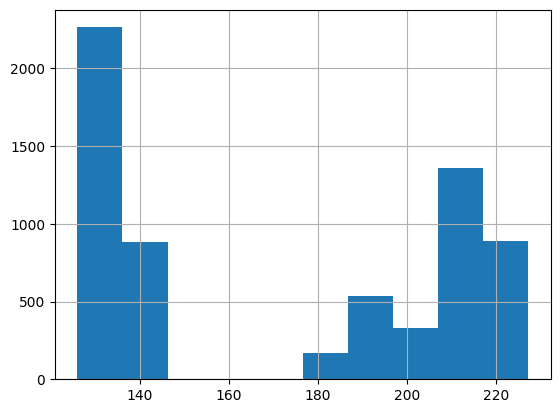

In [18]:
# X axis as CPI, Y-axis as count
df_sales['CPI'].hist()

In [19]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'], dayfirst=True)

**Central tendancy values(discreate statistical analysis)**

In [20]:
df_sales.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


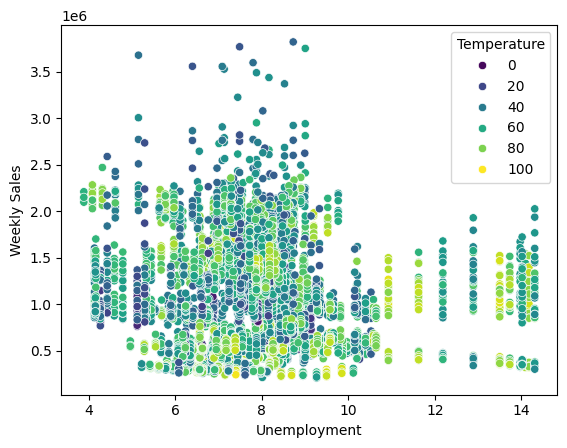

In [21]:
# plt.scatter(df_sales['Unemployment'], df_sales['Weekly_Sales'])
sns.scatterplot(df_sales, x='Unemployment', y='Weekly_Sales',
                hue=df_sales['Temperature'], palette='viridis')
plt.ylabel('Weekly Sales')
plt.show()

**Checking outliers**

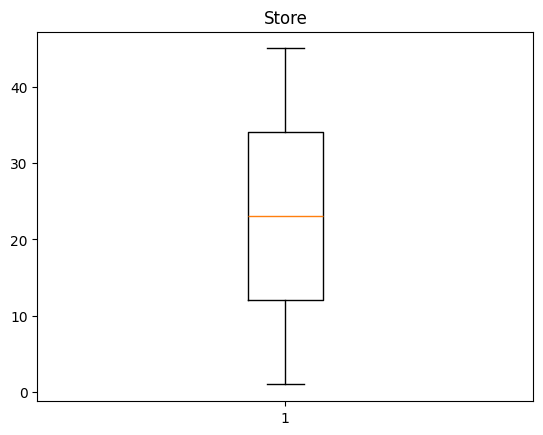

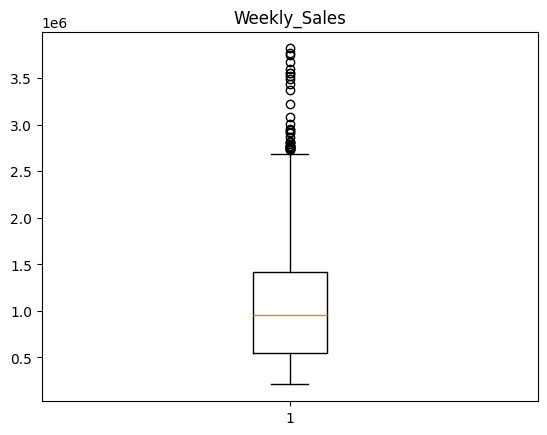

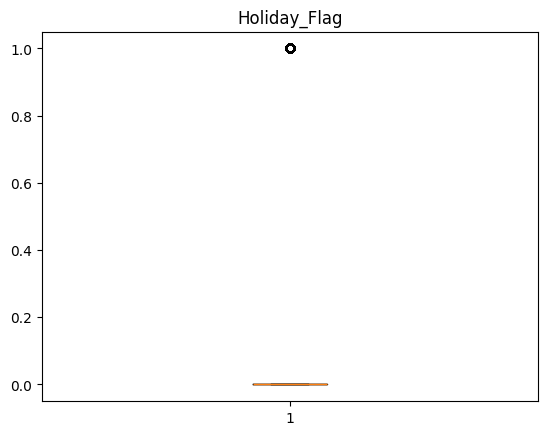

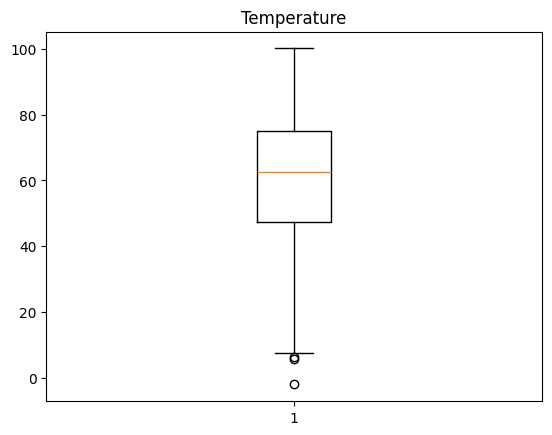

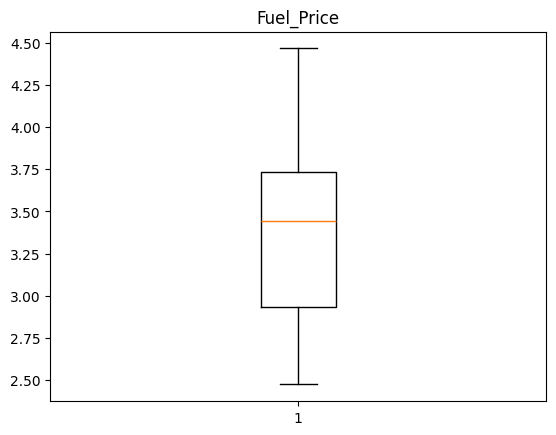

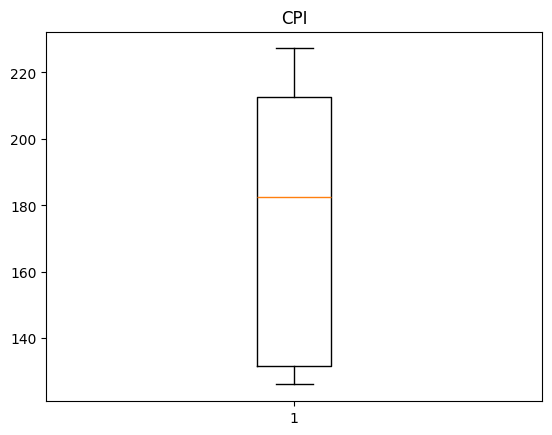

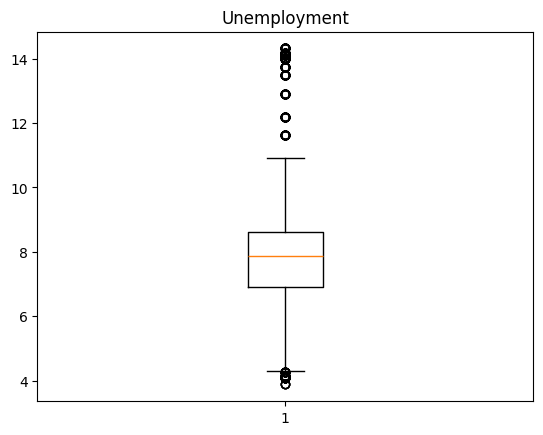

In [22]:
# box plot to identify features having outliers
for cname in df_sales.columns:
  if df_sales[cname].dtype in ['int', 'float']:
    plt.boxplot(df_sales[cname])
    plt.title(cname)
    plt.show()

In [23]:
# caluclate outliers
outlier_columns = ['Weekly_Sales', 'Temperature', 'Unemployment']
for col in outlier_columns:
  q1 = df_sales[col].quantile(0.25)
  q3 = df_sales[col].quantile(0.75)
  IQR = q3 - q1
  lower_limt = q1 - IQR * 1.5
  ubber_limit = q3 + IQR * 1.5
  df_sales = df_sales[(df_sales[col] >= lower_limt) & (df_sales[col] <= ubber_limit)]

In [24]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5917 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         5917 non-null   int64         
 1   Date          5917 non-null   datetime64[ns]
 2   Weekly_Sales  5917 non-null   float64       
 3   Holiday_Flag  5917 non-null   int64         
 4   Temperature   5917 non-null   float64       
 5   Fuel_Price    5917 non-null   float64       
 6   CPI           5917 non-null   float64       
 7   Unemployment  5917 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 416.0 KB


**a. If the weekly sales are affected by the unemployment rate, if yes - which stores
 are suffering the most?**

 H0 - Weekly sales are **not** affected by unemployment rate

 H1 - Weekly sales are affected by unemployment rate

<BarContainer object of 5917 artists>

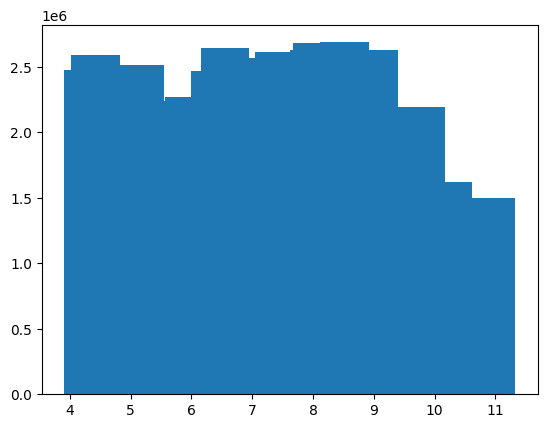

In [25]:
plt.bar(df_sales['Unemployment'], df_sales['Weekly_Sales'])

In [26]:
from scipy.stats import pearsonr

In [27]:
# Statistical test using pearson correlation
r, pvalue = pearsonr(df_sales['Unemployment'], df_sales['Weekly_Sales'])
print(r, pvalue)
if pvalue < 0.05:
  print('Statistically significant, reject null hypothesis')
  if r < 0:
    print('So, there is negative correlation b/w Unemployment and Weekly Sales.')
    print('Hence, When Unemployment increase Weekly Sales sluggish as per sample data')
else:
  print('Statistically insignificant, fail to reject null hypothesis')

-0.07309164834106421 1.8157262632632586e-08
Statistically significant, reject null hypothesis
So, there is negative correlation b/w Unemployment and Weekly Sales.
Hence, When Unemployment increase Weekly Sales sluggish as per sample data


In [28]:
# Statistical test using regression, to anlyse the relation b/w 2 variables:
import statsmodels.api as sm

In [29]:
X = sm.add_constant(df_sales['Unemployment'])
y = df_sales['Weekly_Sales']
model_ols = sm.OLS(y, X)
result = model_ols.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weekly_Sales   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     31.77
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           1.82e-08
Time:                        09:56:25   Log-Likelihood:                -86609.
No. Observations:                5917   AIC:                         1.732e+05
Df Residuals:                    5915   BIC:                         1.732e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          1.29e+06    4.5e+04     28.647      0.000     1.2e+06    1.38e+06
Unemployment -3.245e+04   5756.605     -5.636      0.000   -4.37e+04   -2.12e+04
==============================================================================
Omnibus:                      602.614   Durbin-Watson:                   0.086
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              364.276
Skew:                           0.477   Prob(JB):                     7.92e-80
Kurtosis:                       2.247   Cond. No.                         50.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**find which stores are affect most by unemployment and least affected store**

In [30]:
# for correlation b/w weekly sales and unemployment for each stroe wise
# df_corr = df_sales.groupby(by='Store')[['Unemployment', 'Weekly_Sales']].corr()\
#     .iloc[0::2,-1].reset_index().iloc[:,[0,2]].sort_values(by='Weekly_Sales')
ser_corr = df_sales.groupby(by='Store')[['Weekly_Sales', 'Unemployment']]\
    .apply(lambda g: g['Unemployment'].corr(g['Weekly_Sales']))\
    .sort_values()
print(ser_corr.head(), ser_corr.tail().sort_values(ascending=False), sep='\n\n')

Store
44   -0.780076
4    -0.633422
13   -0.400254
39   -0.384681
42   -0.356355
dtype: float64

Store
36    0.833734
35    0.483865
14    0.269510
21    0.218367
30    0.201862
dtype: float64


**b. If the weekly sales show a seasonal trend, when and what could be the reason?**

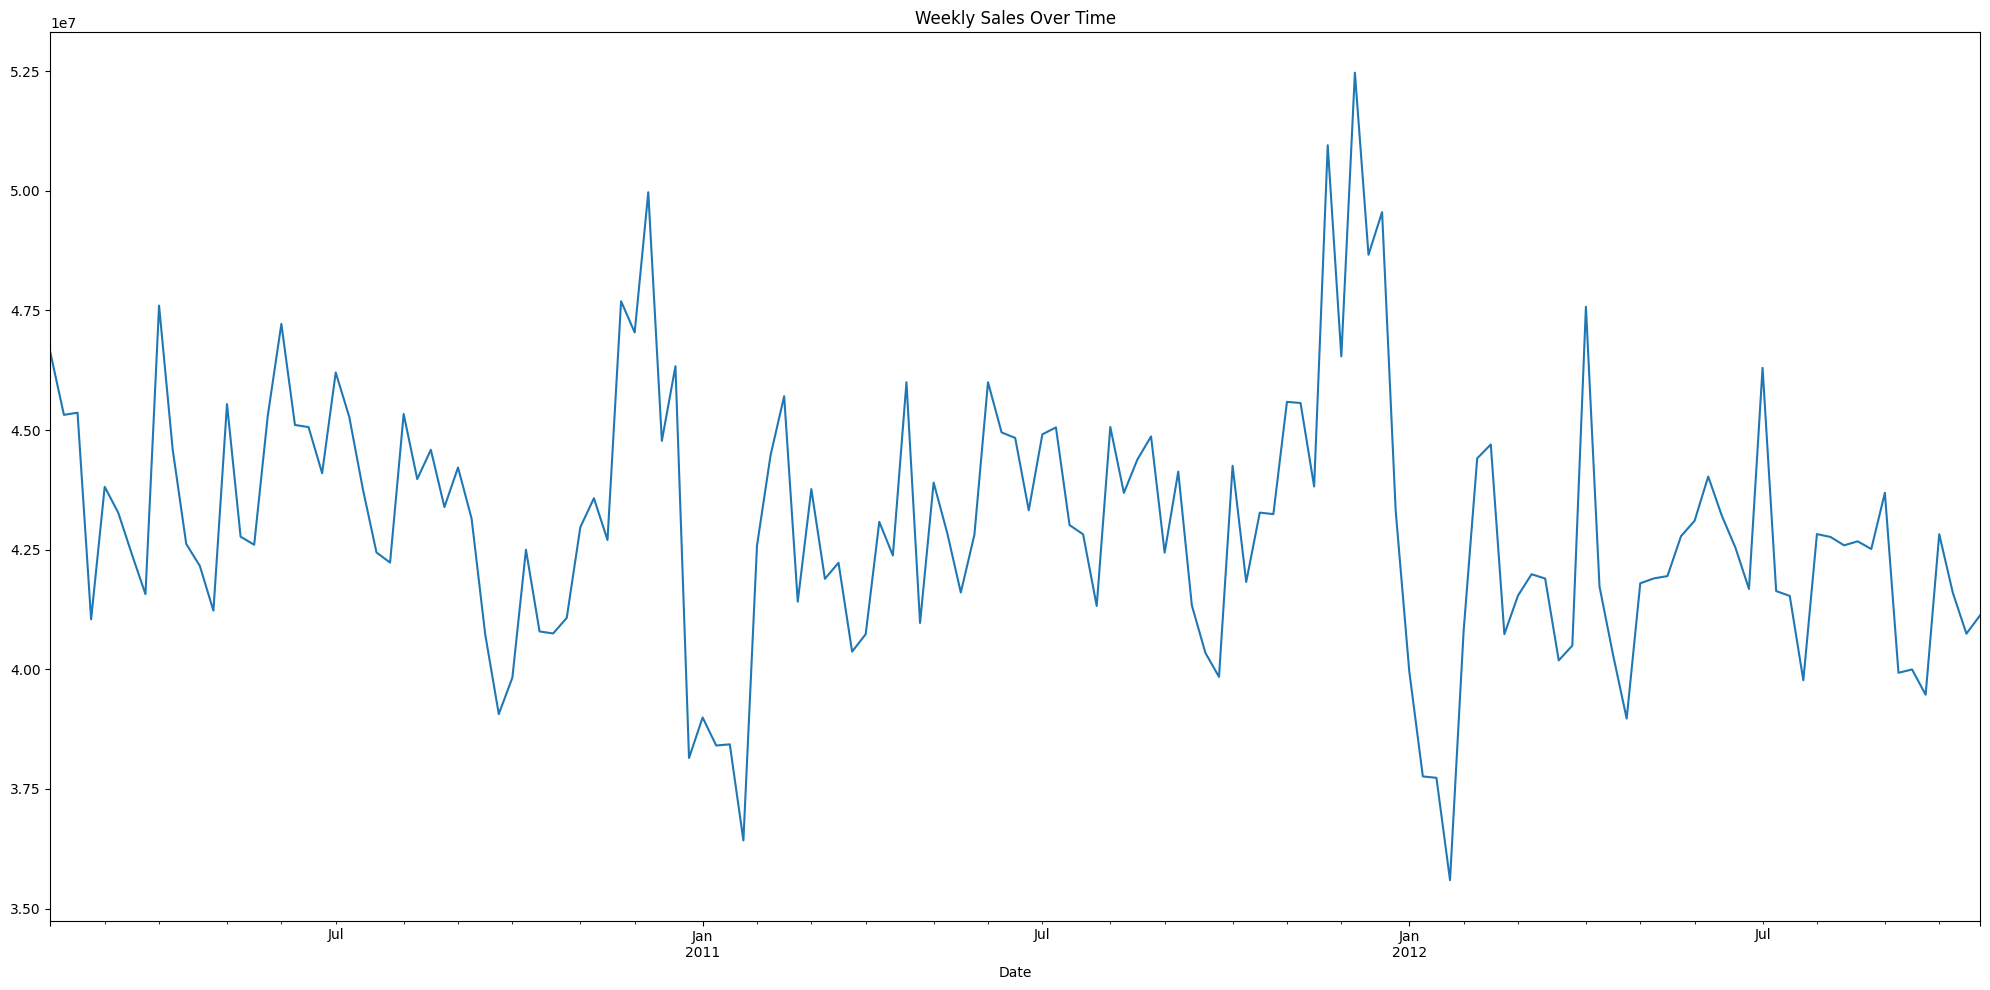

In [31]:
# df_sales[df_sales['Store'] == 1]['Weekly_Sales'].plot()
plt.figure(figsize=(20,10))
df_sales.groupby(by='Date')['Weekly_Sales'].sum().plot()
plt.title('Weekly Sales Over Time')
plt.tight_layout()
plt.show()

In [32]:
# pd.plotting.register_matplotlib_converters()
df_sales = df_sales_org.copy(deep=True)
df_sales['Date'] = pd.to_datetime(df_sales['Date'], dayfirst=True)

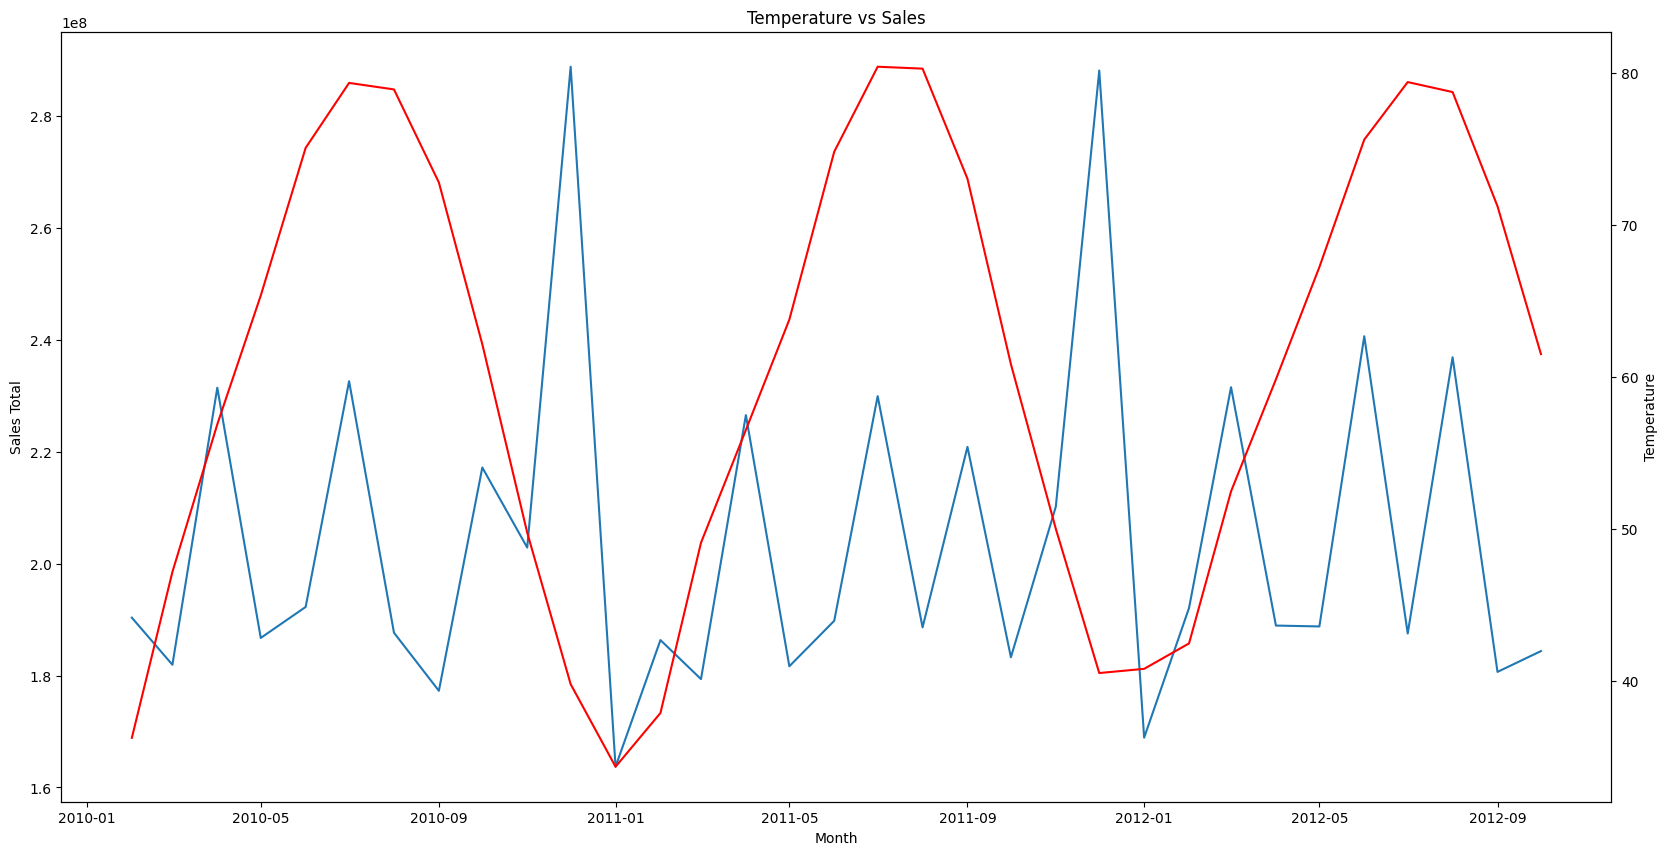

In [33]:
df_monthly_sales = df_sales.groupby(by=df_sales['Date']
                                     .dt.to_period('M')
                                     )[['Weekly_Sales', 'Temperature']]\
                                     .agg({'Weekly_Sales': 'sum',
                                           'Temperature': 'mean'}).reset_index()
# print(df_monthly_sales)
df_monthly_sales['Date'] = df_monthly_sales['Date'].dt.to_timestamp()
df_monthly_sales.rename(columns={'Weekly_Sales': 'Monthly_Sales'}, inplace=True)
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.plot(df_monthly_sales['Date'],
         df_monthly_sales['Monthly_Sales'])
ax1.set_ylabel('Sales Total')

ax2 = ax1.twinx()
ax2.plot(df_monthly_sales['Date'],
         df_monthly_sales['Temperature'],
         color='red')
ax2.set_ylabel('Temperature')

plt.title('Temperature vs Sales')
ax1.set_xlabel('Month')
plt.show()

In [34]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.5 MB/s eta 0:00:00


In [35]:
from pmdarima import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [36]:
df_sales = df_sales_org.copy(deep=True)
df_sales['Date'] = pd.to_datetime(df_sales['Date'], dayfirst=True)

In [37]:
df_sales = df_sales.set_index('Date').sort_index()
# df_sales = df_sales.to_period('W').to_timestamp()
# df_sales

In [38]:
df_monthly_sales = df_monthly_sales.set_index('Date').sort_index()

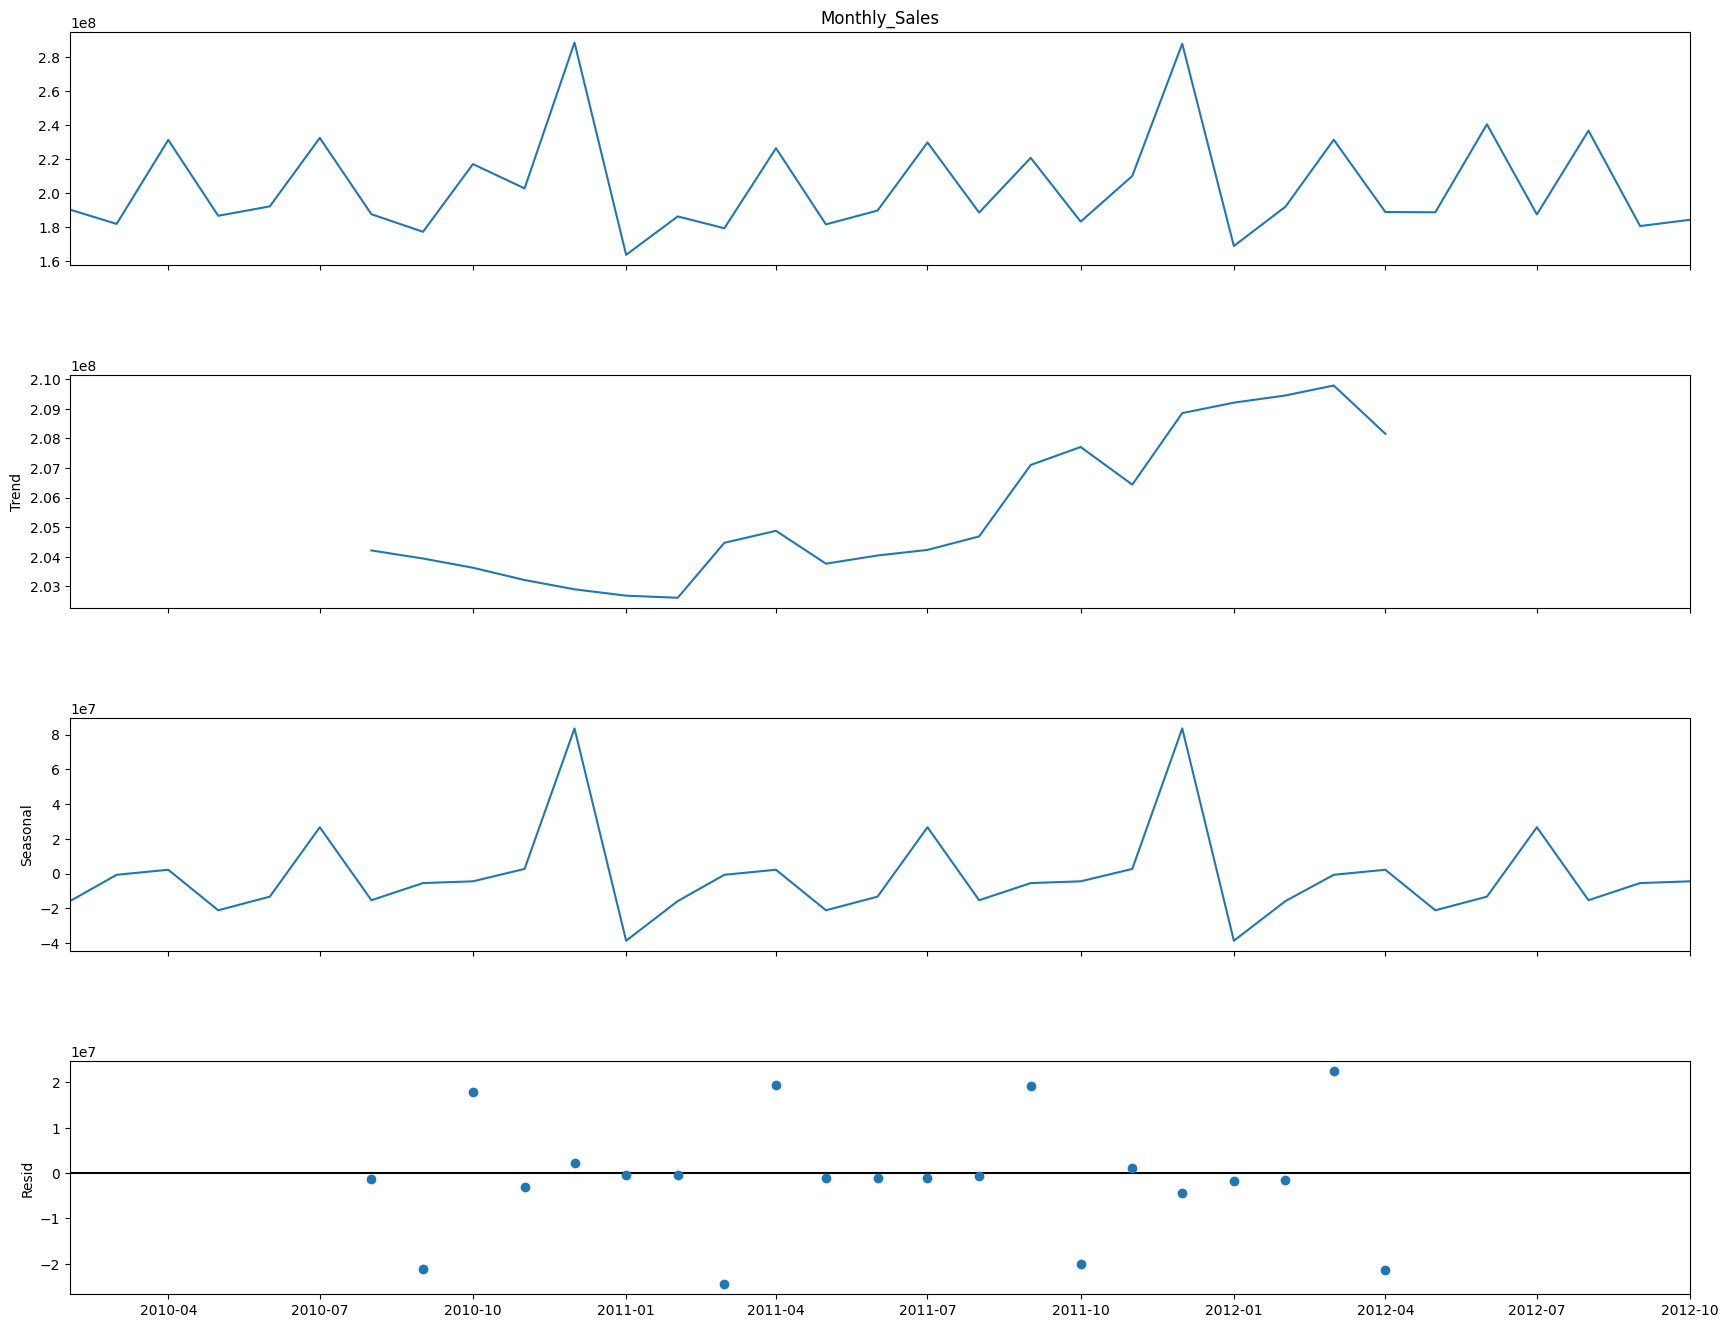

In [39]:
decompose_result2 = seasonal_decompose(df_monthly_sales['Monthly_Sales'], period=12)
fig2 = decompose_result2.plot()
fig2.set_size_inches((20,15))

 b. If the weekly sales show a seasonal trend, when and what could be the reason?

 **Yes, in month of January and Febrauary sales plunge due to low temperature, season with moderate temperatue register peak sales. However, high temperature also affects the sales but not as low temperature.**

In [40]:
###

 c. Does temperature affect the weekly sales in any manner?

  **Yes, in month of January and Febrauary sales plunge due to low temperature, season with moderate temperatue register peak sales. However, high temperature also affects the sales but not as low temperature.**

**d. How is the Consumer Price index affecting the weekly sales of various stores?**

In [41]:
df_sales['CPI'].corr(df_sales['Weekly_Sales'])

-0.0726341620401763

In [42]:
pearsonr(df_sales['CPI'], df_sales['Weekly_Sales'])

PearsonRResult(statistic=-0.07263416204017628, pvalue=5.438292612176922e-09)

<Axes: >

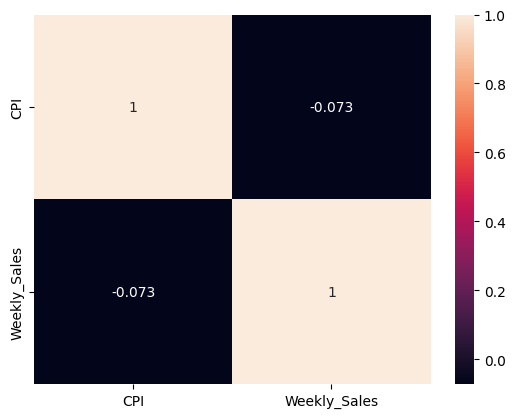

In [43]:
sns.heatmap(df_sales[['CPI', 'Weekly_Sales']].corr(), annot=True)

**There is negative correlation between Consumer Price Index and Weekly Sales, and Pearsonr's p-value is less than siginficance level(0.05), which indicates when CPI increases the sales is decreased (i.e. high product prices leads to lesser sales)**

**e. Top performing stores according to the historical data.**

In [44]:
best_stores = df_sales.groupby(by='Store')['Weekly_Sales']\
.sum().sort_values(ascending=False).head()
best_stores

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08


**f.
 The worst performing store, and how significant is the difference between the
 highest and lowest performing stores.**

In [45]:
least_stores = df_sales.groupby(by='Store')['Weekly_Sales']\
.sum().sort_values(ascending=True).head()
least_stores

,Weekly_Sales
Store,
33,37160221.96
44,43293087.84
5,45475688.90
36,53412214.97
38,55159626.42


In [46]:
#difference
sales_diff = (
    best_stores.reset_index()['Weekly_Sales'] -
    least_stores.reset_index()['Weekly_Sales']
)
sales_diff

,Weekly_Sales
0,2.642376e+08
1,2.562509e+08
2,2.435242e+08
3,2.331055e+08
4,2.202228e+08


<BarContainer object of 6435 artists>

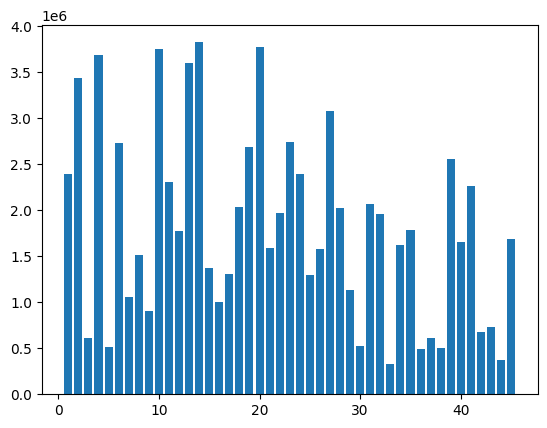

In [47]:
plt.bar(df_sales['Store'], df_sales['Weekly_Sales'])

how significant is the difference between the highest and lowest performing stores:

i.e. Statistically analyse, whether the difference b/w the well performed stores and poorly performed stores are statistically siginficant or just random chance.

H0 - There is no difference between highly performed stores and poorly performed stroes on their weekly sales.

H1 - There is signficant difference between highly performed stores and poorly performed stroes on their weekly sales.

In [48]:
from scipy.stats import ttest_ind

In [49]:
score, pval = ttest_ind(best_stores, least_stores, equal_var=False)
print(score, pval)

42.13886215109036 7.375205514911991e-10


**p-value < 0.05(significance level). Hence, reject the Null hypothesis. Thus, difference between the highest and lowest performing stores is statistically significant.**

In [50]:
###

 **2. Use predictive modeling techniques to forecast the sales for each store for the next 12
 weeks.**

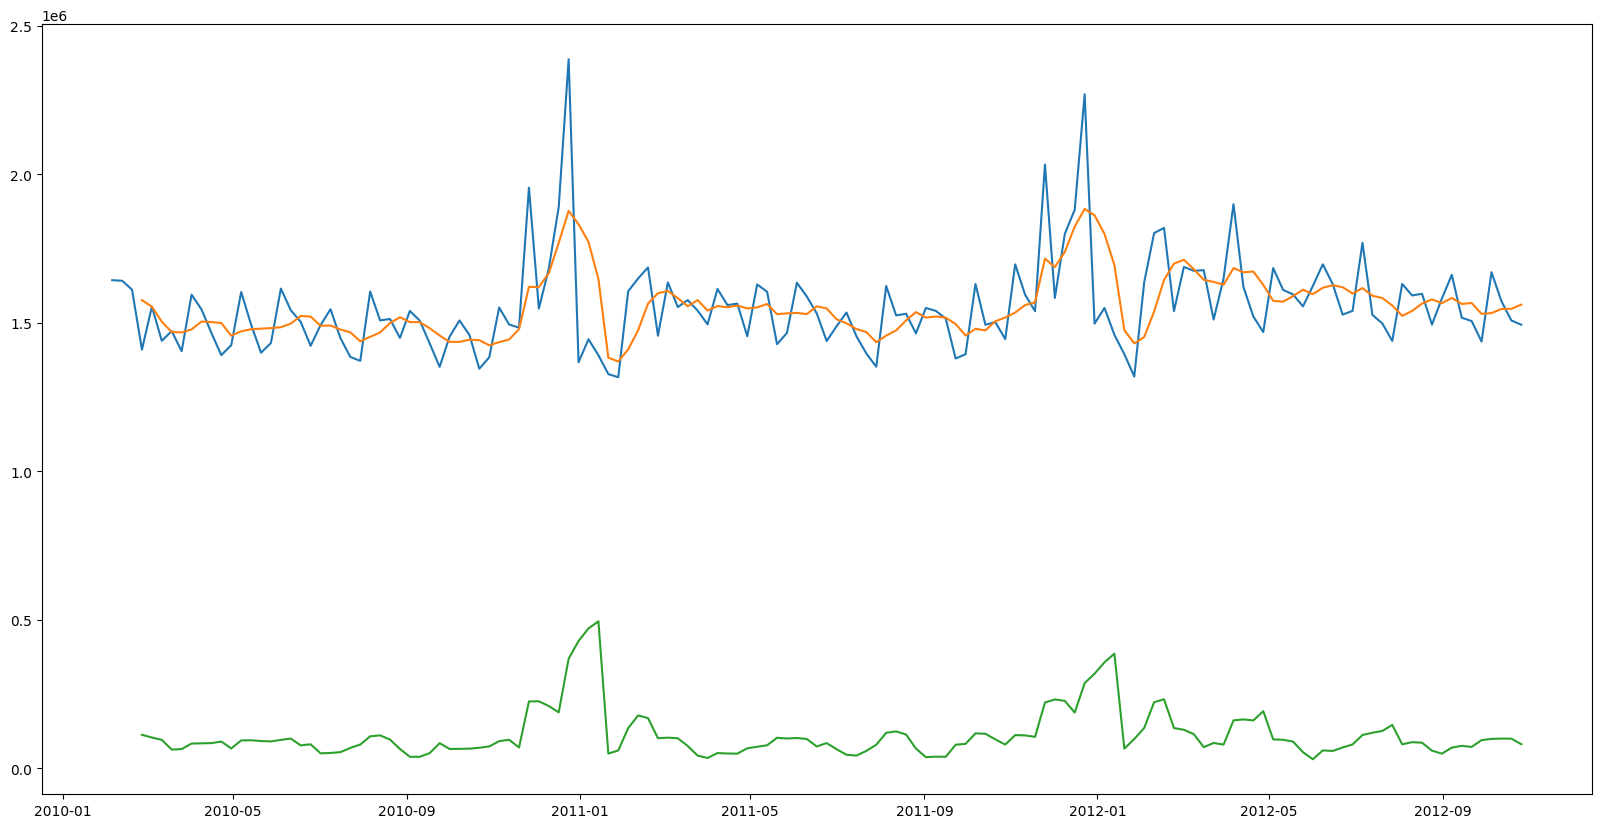

In [51]:
#Anlyse the time series data for store-1
sales_mean = df_sales[df_sales['Store']==1]['Weekly_Sales'].rolling(window=4).mean()
sales_std = df_sales[df_sales['Store']==1]['Weekly_Sales'].rolling(window=4).std()
plt.figure(figsize=(20,10))
plt.plot(df_sales[df_sales['Store']==1]['Weekly_Sales'])
plt.plot(sales_mean)
plt.plot(sales_std)
plt.show()

Plot multiple store with test statistics, and compine adfuller test result to check stationarity.

Checking Stationarity using AdFuller Test

H0 - Data is not stationary

H1 - Data is stationary

In [52]:
from statsmodels.tsa.stattools import adfuller

In [53]:
store_ids = np.sort(df_sales['Store'].unique())
store_ids[:]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [54]:
def stationarity_report(adf_sales:pd.DataFrame,
                        sids:np.ndarray,
                        figsize=(25,12))->list:
    fig, axes = plt.subplots(len(sids)//3 + 1, 3,
                             figsize=figsize, sharex=True)
    non_stationary_sids = list()
    for ax, sid in zip(axes.flatten(), sids):
      # print(ax, sid)
      ax.plot(adf_sales[adf_sales['Store'] == sid]['Weekly_Sales'])
      ax.plot(adf_sales[adf_sales['Store'] == sid]['Weekly_Sales']
              .rolling(window=4).mean()) #'r:'
      ax.plot(adf_sales[adf_sales['Store'] == sid]['Weekly_Sales']
              .rolling(window=4).std()) #'g'
      adfull_pval = adfuller(adf_sales[adf_sales['Store'] == sid]['Weekly_Sales'])[1]
      ax.set_title(f'Store Id: {sid}  AdfPval: {adfull_pval:.5f} -'
                  f'{"Stationary" if adfull_pval <= 0.05 else "Not Stationary"}')
      # ax.legend()
      if adfull_pval > 0.05:
         non_stationary_sids.append(sid)
    # for ax in axes.flatten()[len(sids):]:
    #   ax.axis('off')
    plt.tight_layout()
    plt.show()
    return non_stationary_sids


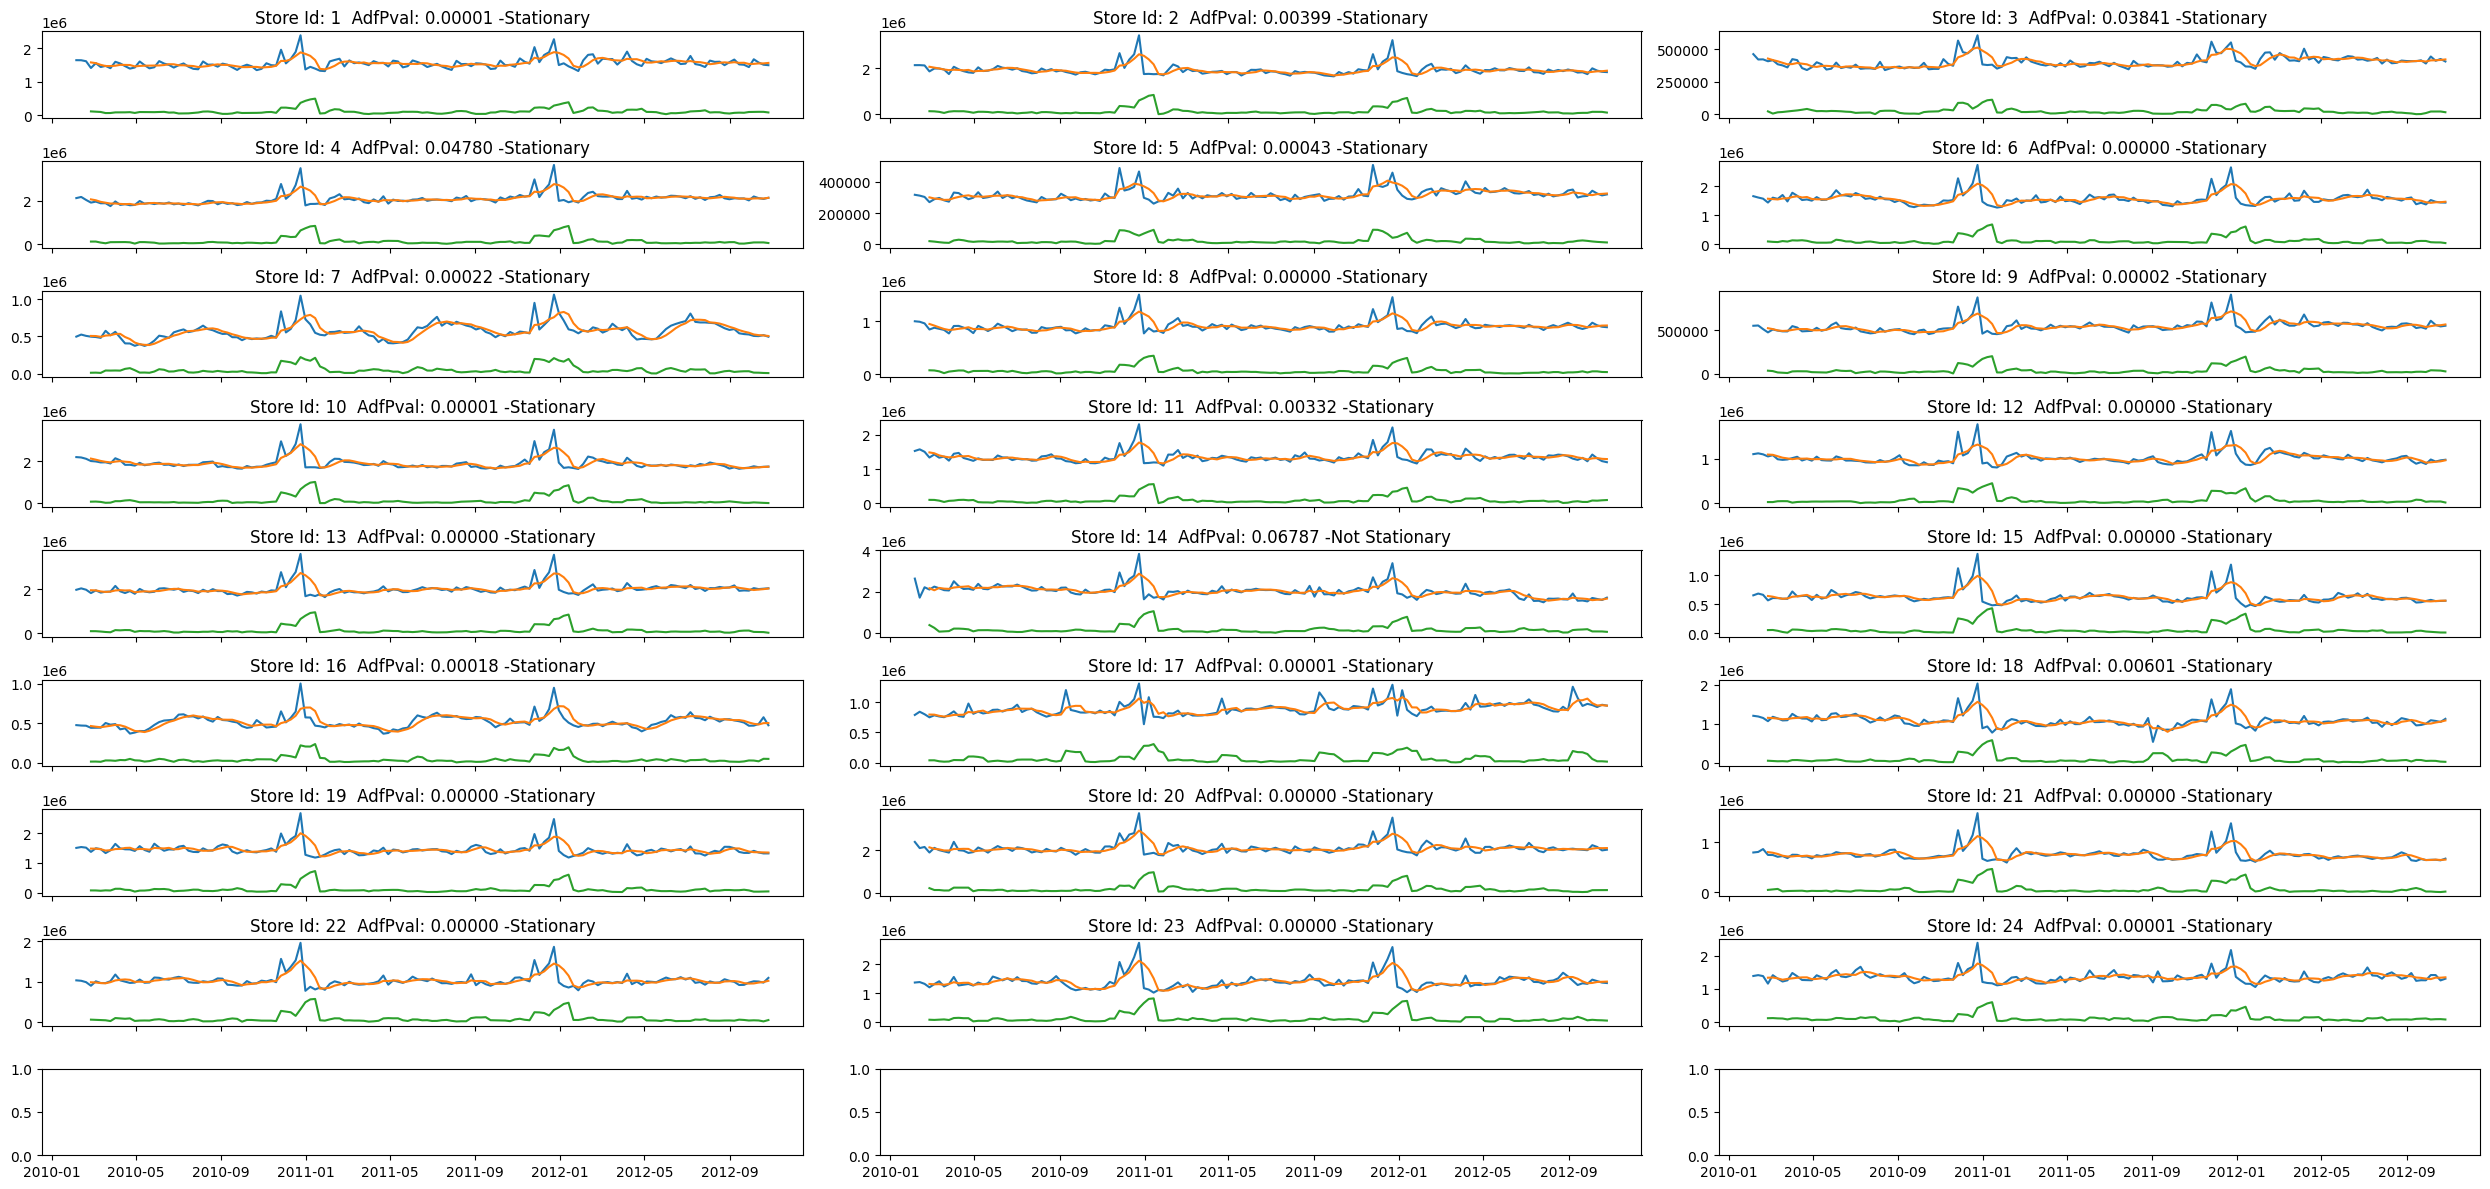

In [55]:
nonsta_sids = stationarity_report(df_sales, store_ids[:24])
# blue - Weekly values
# red - rolling mean(moving average)
# green - Standard deviation

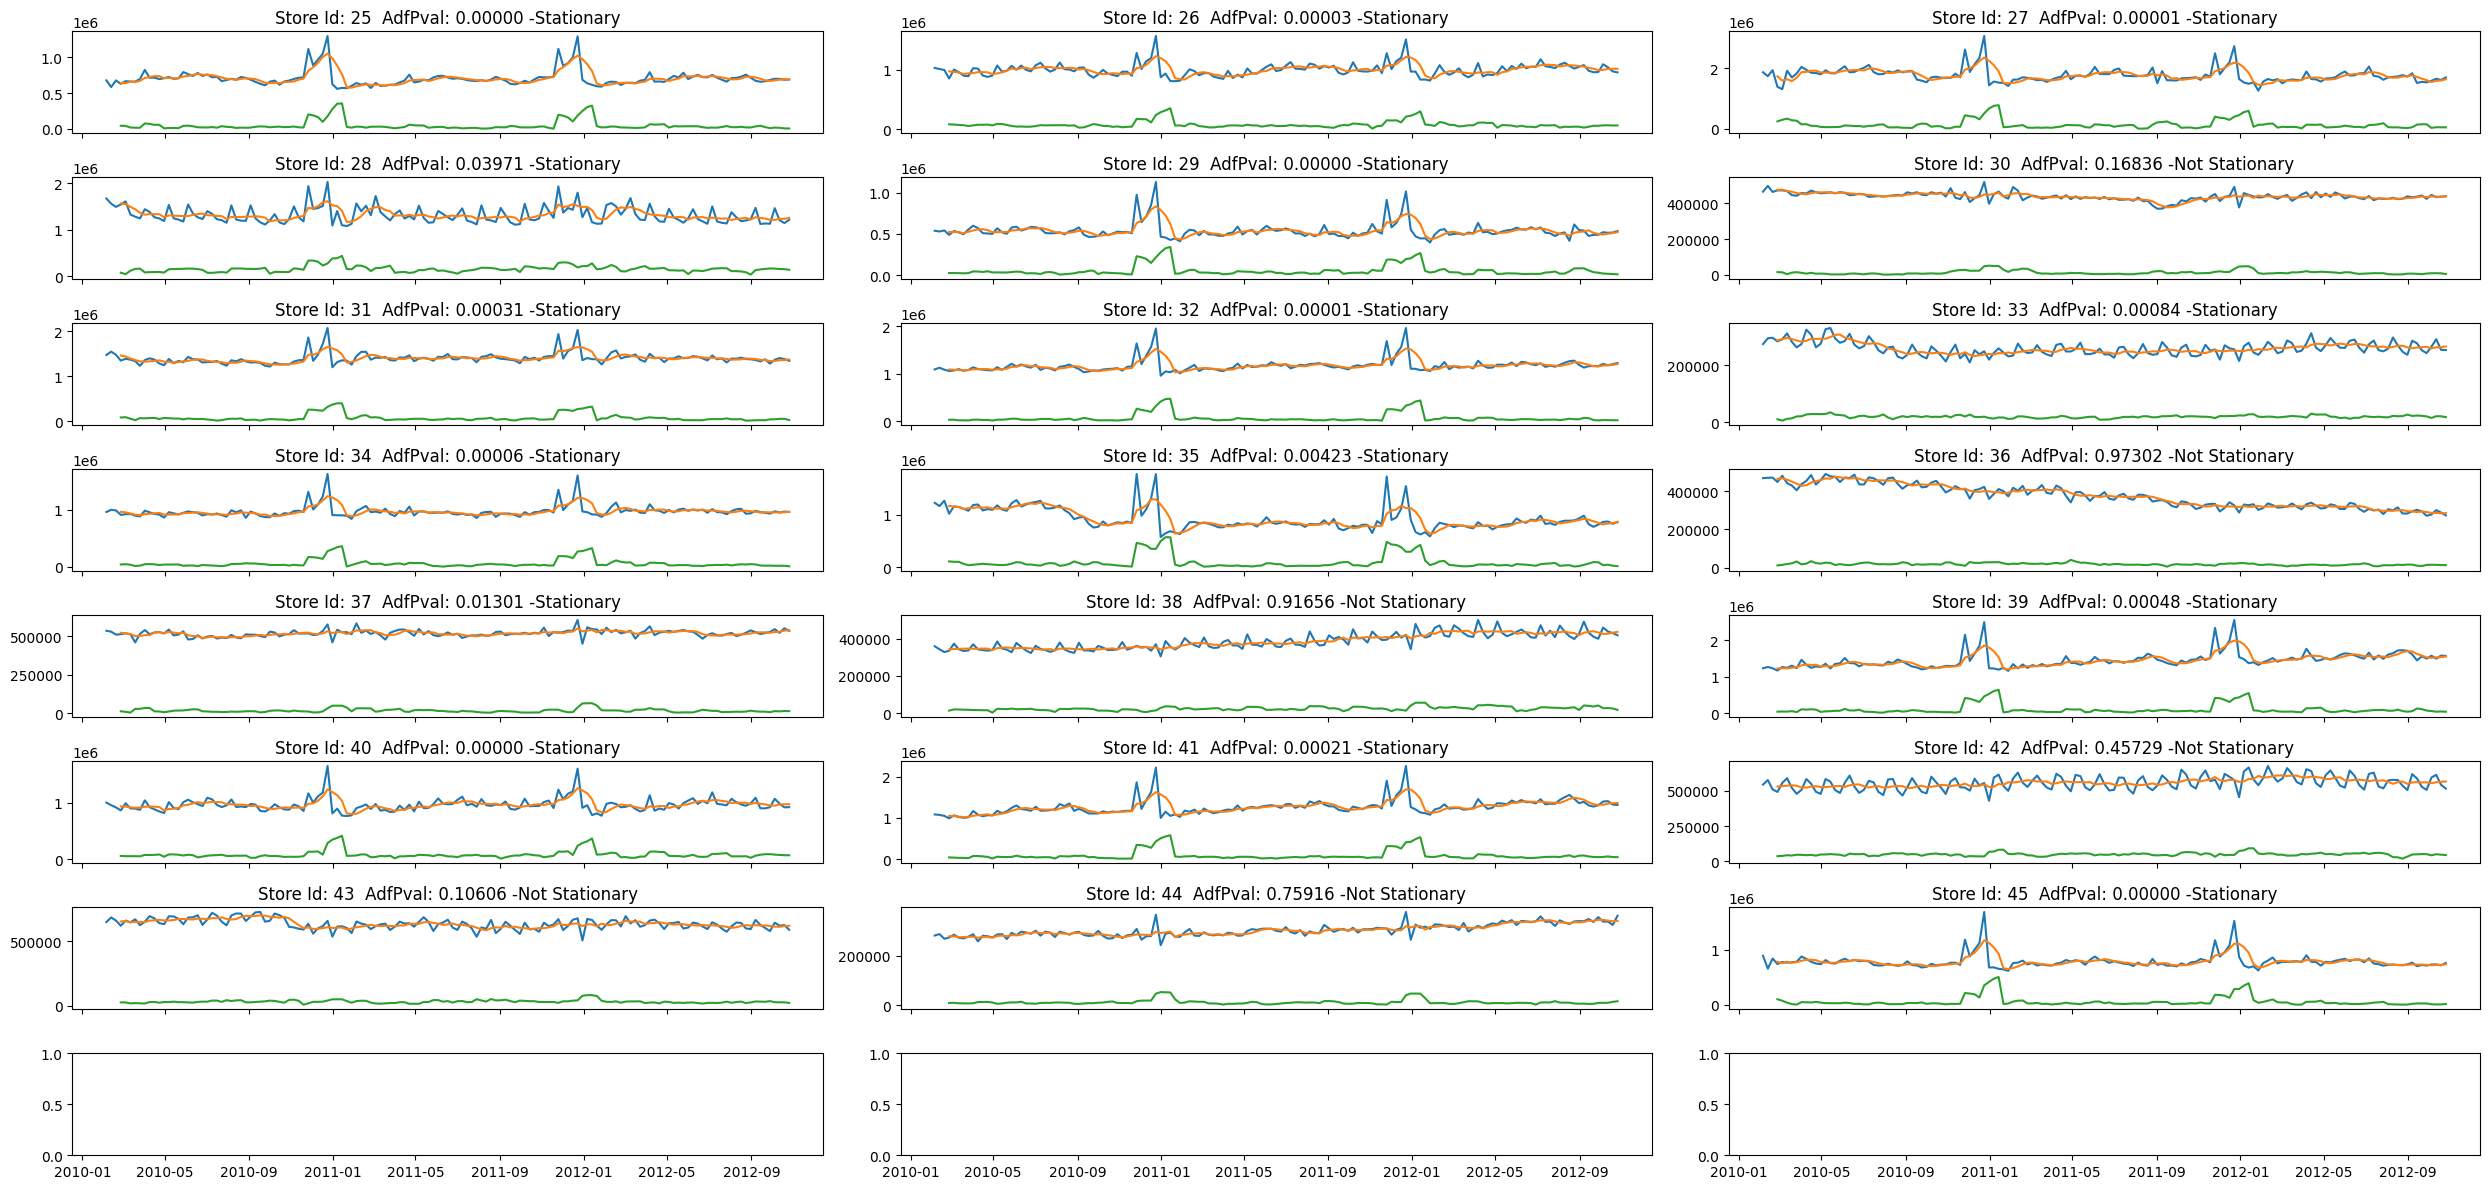

In [56]:
nonsta_sids += stationarity_report(df_sales, store_ids[24:])
# blue - Weekly values
# red - rolling mean(moving average)
# green - Standard deviation

In [57]:
nonsta_sids = np.array([*set(nonsta_sids)])
nonsta_sids

array([36, 38, 42, 43, 44, 14, 30])

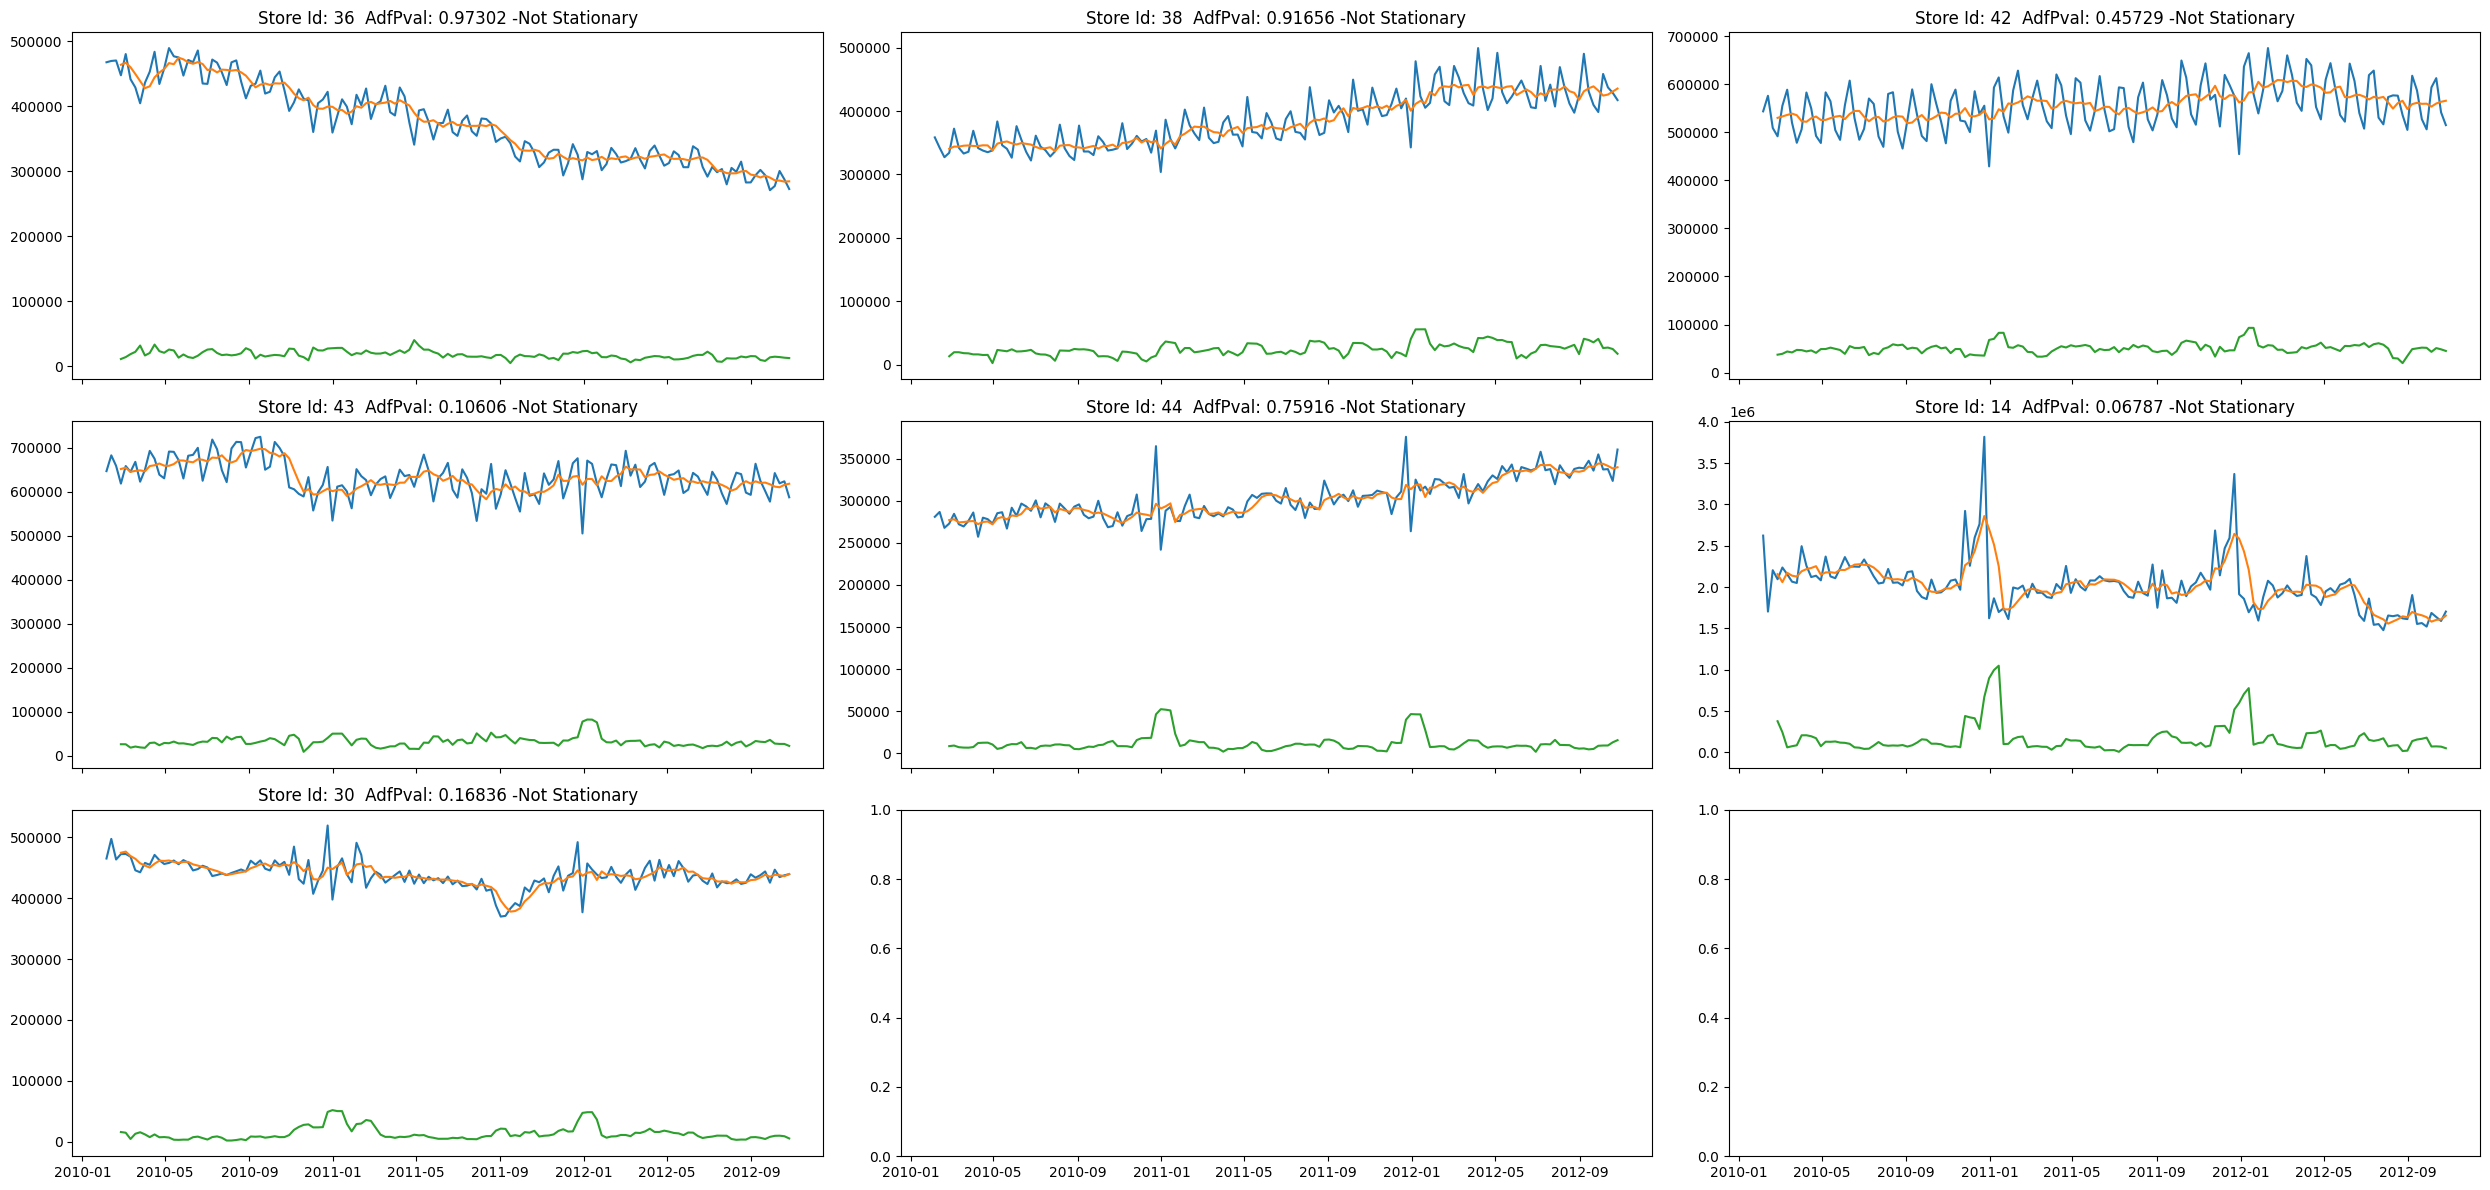

[36, 38, 42, 43, 44, 14, 30]

In [58]:
stationarity_report(df_sales, nonsta_sids)

In [59]:
df_sales.loc[df_sales['Store'].isin(nonsta_sids), ['Store','Weekly_Sales']]

,Store,Weekly_Sales
Date,,
2010-02-05,30,465108.52
2010-02-05,38,358496.14
2010-02-05,36,467546.74
2010-02-05,42,543384.01
2010-02-05,43,647029.28
...,...,...
2012-10-26,30,439424.50
2012-10-26,44,361067.07
2012-10-26,38,417290.38


In [60]:
df_sales.columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='object')

In [61]:
# only for non-stationary stores data
df_sales_log = df_sales.loc[df_sales['Store'].isin(nonsta_sids)]
df_sales_log = df_sales_log.sort_index()

In [62]:
# remove trends using mean differencing and make data stationary.
for sid in nonsta_sids:
  df_sales_log.loc[df_sales_log['Store']==sid, 'Weekly_Sales'] = \
     df_sales_log.loc[df_sales_log['Store']==sid, 'Weekly_Sales'].diff()
df_sales_log = df_sales_log.dropna()
df_sales_log['Store'].unique()

array([43, 38, 36, 42, 14, 30, 44])

In [63]:
for sid in nonsta_sids:
  print(adfuller(df_sales_log.loc[df_sales_log['Store']==sid,
                                  'Weekly_Sales'])[1])

0.00079075913196934
5.901458881335997e-05
0.0009757356359534513
0.0027804734883927927
4.22094240548801e-18
8.464371616908218e-11
2.554473273499668e-10


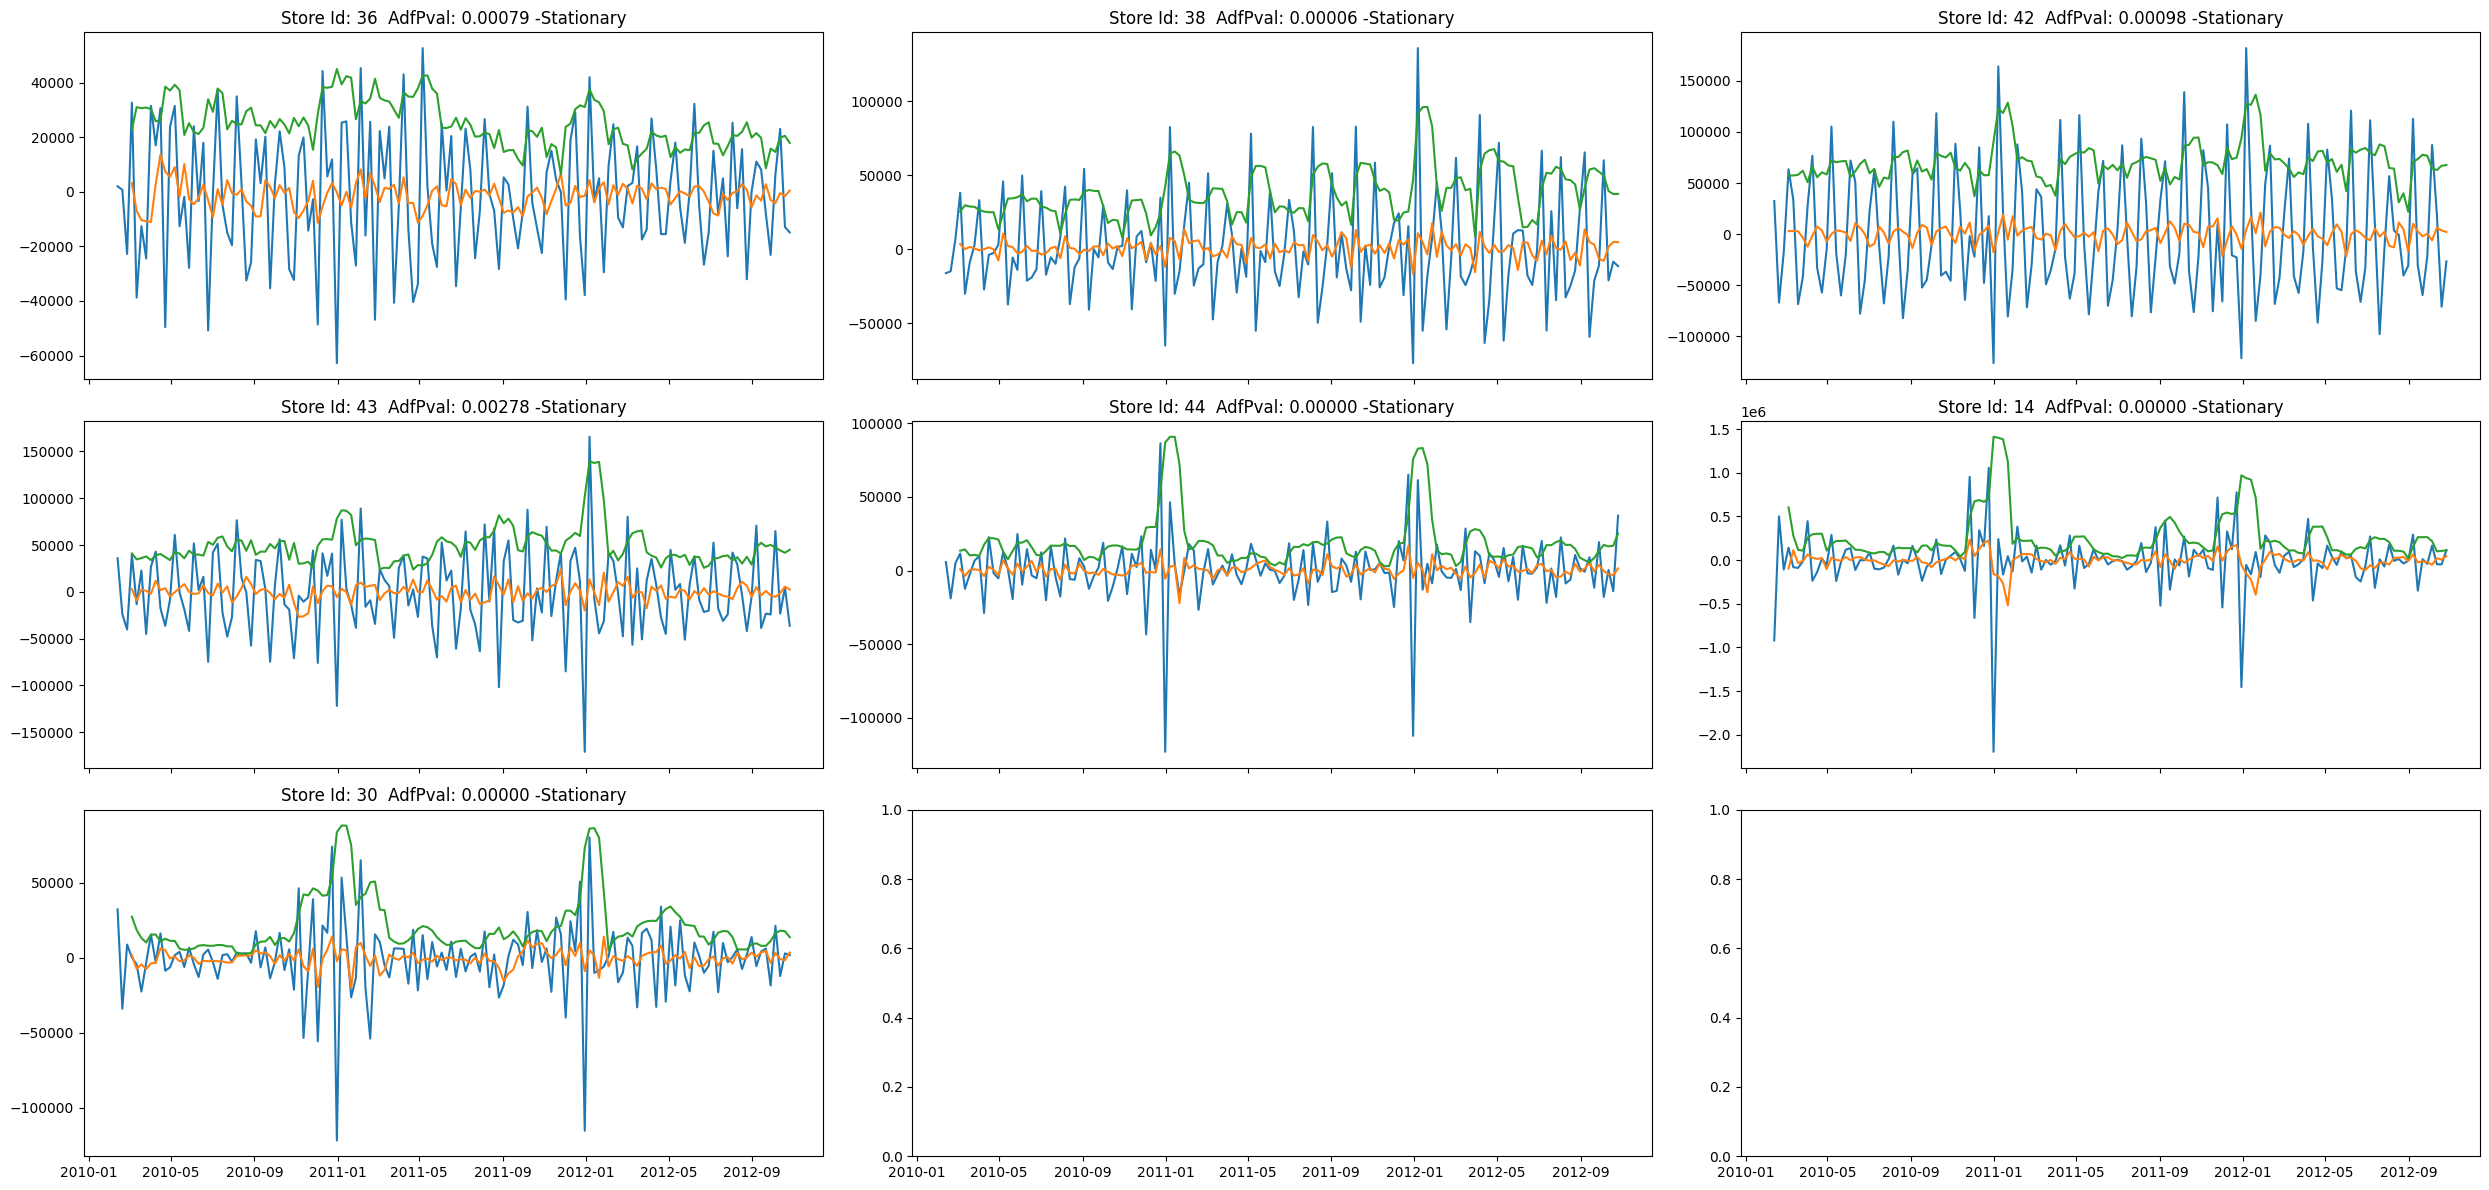

[]

In [64]:
stationarity_report(df_sales_log, nonsta_sids)

In [65]:
# !pip install pmdarima

In [66]:
import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

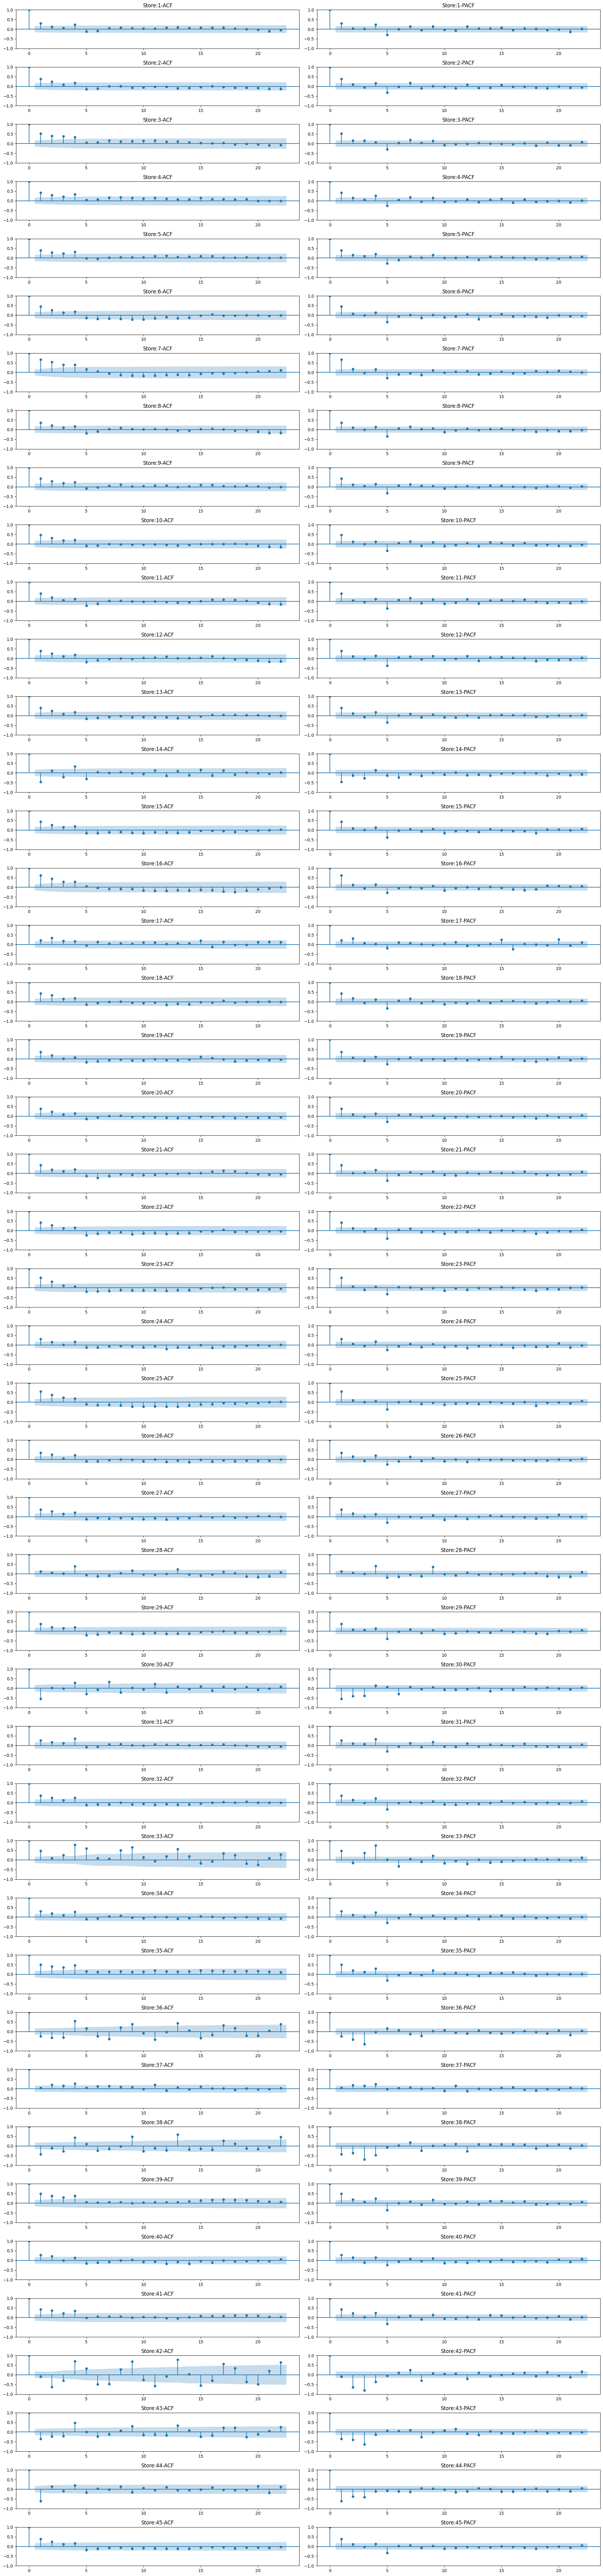

In [67]:
#check model term for each store
fig, axes = plt.subplots(45, 2, figsize=(20, 85))
# print(*zip(axes, store_ids[:6]))
for ax,sid in zip(axes, store_ids):
  if sid in nonsta_sids:
    x = df_sales_log.loc[df_sales_log['Store']==sid, 'Weekly_Sales']
  else:
    x = df_sales.loc[df_sales['Store']==sid, 'Weekly_Sales']
  plot_acf(x, ax=ax[0], title=f'Store:{sid}-ACF')
  plot_pacf(x, ax=ax[1], title=f'Store:{sid}-PACF')

plt.tight_layout()
plt.show()


In [68]:
nonsta_sids = [*set(nonsta_sids)]

**Test data prediction and forecast for next 12 weeks**

Split raw data → train/test

Difference train data (model learns changes)

Forecast differences beyond train

Invert forecasts using last train value

Compare with test

In [69]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [70]:
fweeks = 12; tlimit = 39; test_size = 0.28

In [71]:
def model_train_test_split(store_id:int, exogen=False):
    ser_model_data = df_sales.loc[df_sales['Store']==store_id,'Weekly_Sales']
    df_exogen_data = df_sales.loc[df_sales['Store']==store_id,
        ['CPI','Unemployment','Fuel_Price','Holiday_Flag','Temperature']]
    tlimit = int(ser_model_data.count() * test_size)
    train_data, test_data = ser_model_data[:-tlimit], ser_model_data[-tlimit:]
    if exogen:
      train_exogen, test_exogen = \
        df_exogen_data[:-tlimit], df_exogen_data[-tlimit:]
    else:
      train_exogen = test_exogen = None

    train_data = train_data.diff().dropna()

    return train_data, test_data, \
        train_exogen, test_exogen, tlimit


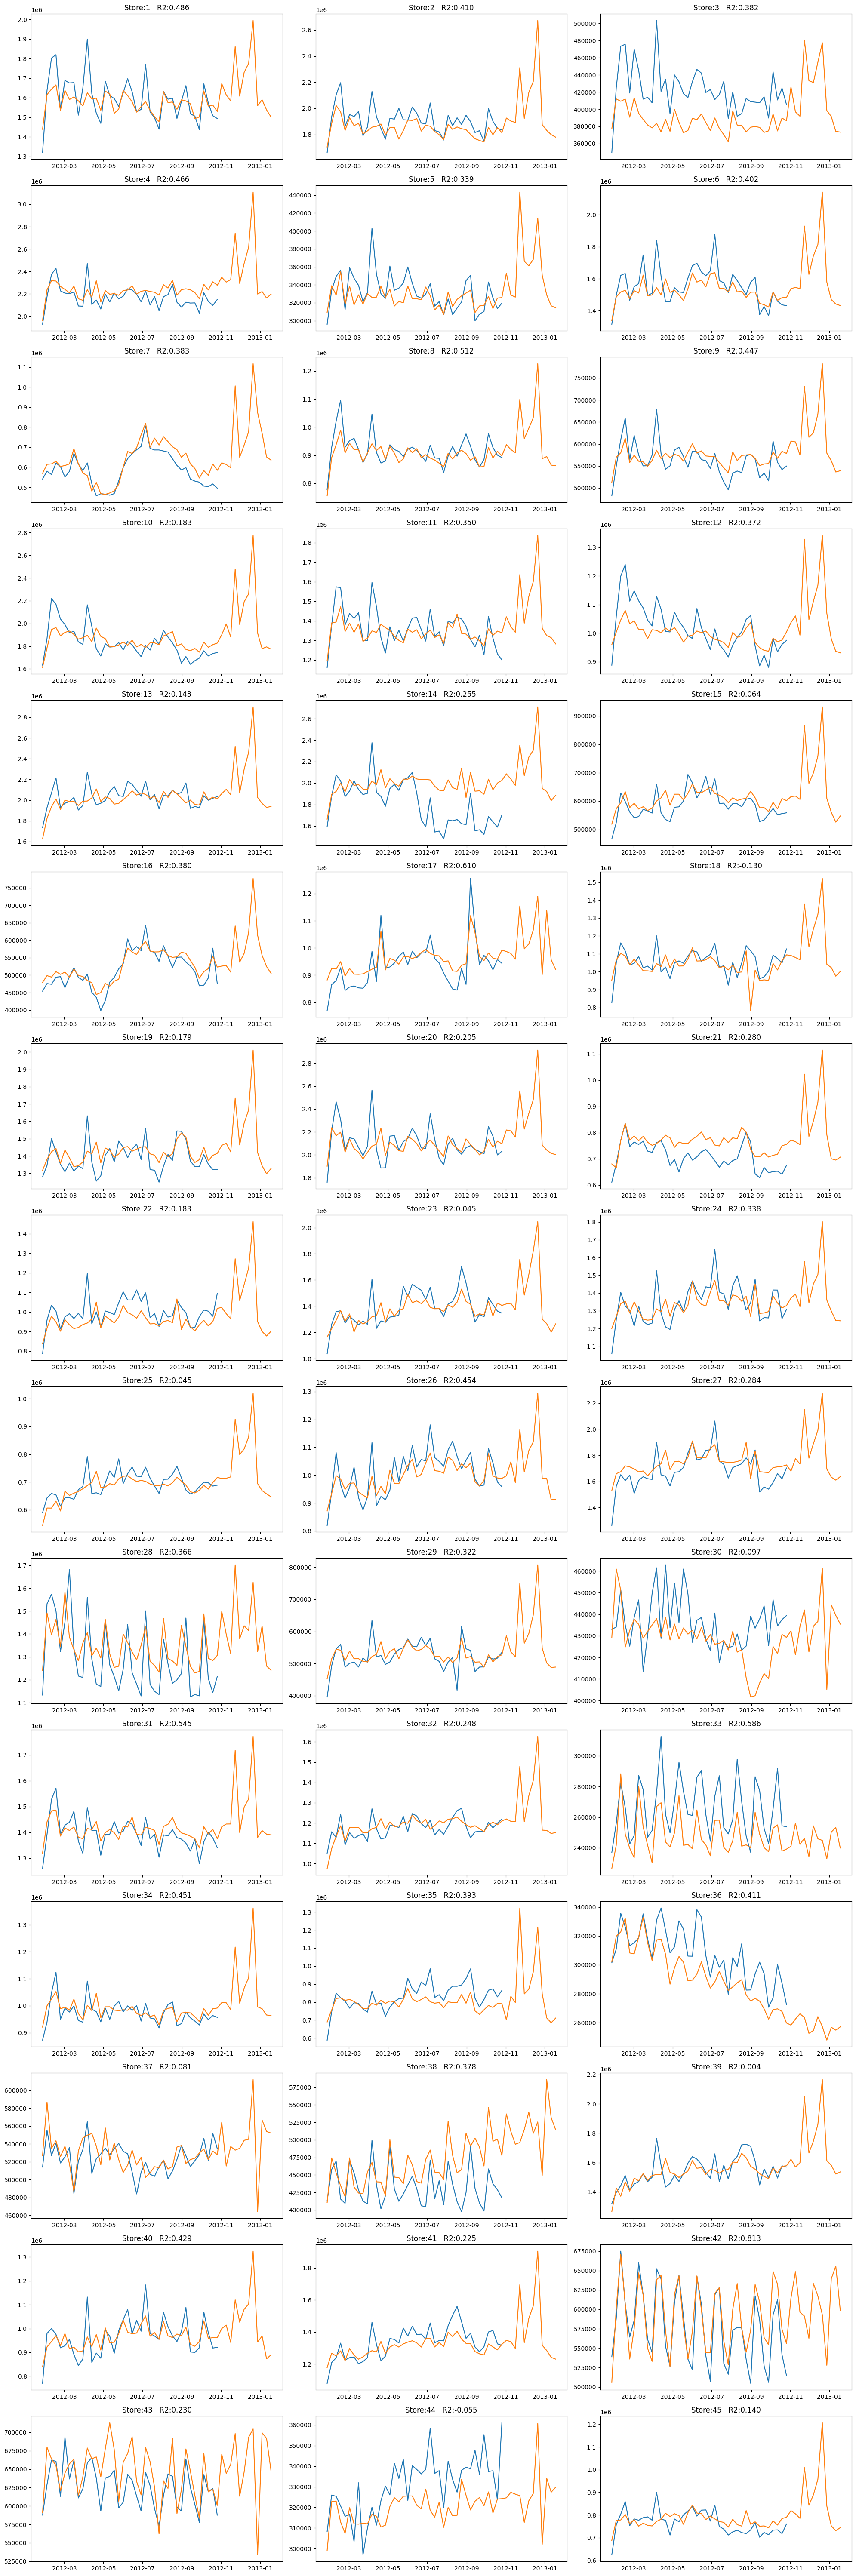

In [85]:
fig, axes = plt.subplots(15, 3, figsize=(20,60))
df_models = pd.DataFrame({'Store': store_ids,
                          'model': np.zeros((len(store_ids),)),
                          'R2': np.zeros((len(store_ids),))})
df_sf = pd.DataFrame({'Store': [], 'Forecast':[]})
for sid, ax in zip(store_ids, axes.flatten()):
  train_data, test_data, train_exogen, test_exogen, tlimit \
                = model_train_test_split(store_id=sid, exogen=False)
  model_store = pm.auto_arima(train_data, train_exogen,
                             seasonal=True, trace=False,
                             d=0, m=52, maxiter=100)
  #forecasting
  forecast = model_store.predict(tlimit+fweeks, X=test_exogen)
  r2 = r2_score(test_data.diff().dropna(), forecast[1:-fweeks])
  # #invert differencing
  forecast = df_sales[df_sales['Store']==sid] \
                  .iloc[-tlimit-1, 1] + np.cumsum(forecast)
  test_pred = forecast[:-fweeks]
  rmse = np.sqrt(mean_squared_error(test_data, test_pred))
  ax.plot(test_data)
  ax.plot(forecast)
  ax.set_title(f'Store:{sid}   R2:{r2:.3f}')

  df_models.loc[df_models['Store']==sid, 'model'] = model_store
  df_models.loc[df_models['Store']==sid, 'R2'] = r2
  df_models.loc[df_models['Store']==sid, 'RMSE'] = rmse.round(3)
  df_sf = pd.concat([df_sf, pd.DataFrame({'Store': sid,
                                         'Forecast': forecast[-fweeks:]},
                                         index=forecast[-fweeks:].index)])
plt.tight_layout()
plt.show()


In [92]:
df_models

,Store,model,R2,RMSE
0,1,"ARIMA(1,0,1)(1,0,0)[52]",0.486371,80146.879
1,2,"ARIMA(4,0,2)(1,0,0)[52]",0.410261,93897.972
2,3,"ARIMA(2,0,0)(1,0,0)[52]",0.382386,43036.500
3,4,"ARIMA(4,0,3)(1,0,0)[52]",0.465575,94383.343
4,5,"ARIMA(0,0,1)(1,0,0)[52]",0.339378,18055.078
5,6,"ARIMA(4,0,3)(1,0,0)[52]",0.402454,85413.048
6,7,"ARIMA(1,0,2)(0,1,0)[52]",0.383151,48424.452
7,8,"ARIMA(5,0,2)(1,0,0)[52]",0.511533,37949.281
8,9,"ARIMA(1,0,1)(1,0,0)[52]",0.446679,29057.823
9,10,"ARIMA(5,0,2)(1,0,0)[52]",0.183176,104718.964


In [93]:
df_sf

,Store,Forecast
2012-11-02,1.0,1.671956e+06
2012-11-09,1.0,1.614333e+06
2012-11-16,1.0,1.583094e+06
2012-11-23,1.0,1.861285e+06
2012-11-30,1.0,1.608219e+06
...,...,...
2012-12-21,45.0,1.206845e+06
2012-12-28,45.0,8.394749e+05
2013-01-04,45.0,7.520400e+05
2013-01-11,45.0,7.309432e+05


**Inferences from the model**

RMSE and R2 indicates moderate predictions.

**Conclusion**

The system effectively predicts. Performance can improve with more data and advanced algorithms.